# TB3 - Caso 1: Regresion logistica para riesgo de listings Airbnb

Este notebook desarrolla el caso de clasificacion binaria solicitado para la TB3 del curso **Analisis Empresarial y Data Science**. El caso se alinea con la TB1/TB2 del proyecto Airbnb: marketplace de confianza, calidad de listings, riesgo operativo, cumplimiento y soporte.

La etiqueta usada no representa disputas reales internas de Airbnb. Como el repositorio no contiene reservas, tickets de soporte ni outcomes de disputa grave, se usa una variable proxy basada en el mart academico `listing_trust_risk` cuando esta disponible. El objetivo es mostrar una implementacion CRISP-DM ejecutable y honesta sobre datos publicos.

In [1]:
# Instalacion opcional si se ejecuta en otro entorno:
# pip install pandas pyarrow numpy scikit-learn matplotlib seaborn joblib nbformat nbclient

## 1. Comprension del negocio

Airbnb funciona como una plataforma de confianza entre huespedes y anfitriones. Para Trust & Safety, Operaciones, Producto y Compliance, una pregunta practica es: **que listings deberian priorizarse para revision o mejora antes de que generen friccion operativa?**

En ausencia de disputas reales, el caso se formula como clasificacion binaria de listings con mayor riesgo o menor confianza operacional. La salida esperada es una probabilidad de `high_risk_listing` que pueda alimentar un dashboard de confianza/riesgo y una cola de revision preventiva.

In [2]:
from pathlib import Path
import math
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for directory in [OUTPUT_DIR, FIG_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Figuras: {FIG_DIR.relative_to(PROJECT_ROOT)}")

Proyecto: c:\Development\ANALISISEMPRESAR-DATASCIENCE-AIRBNB\AirBnB-Analisis-Empresarial
Figuras: outputs\figures


## 2. Comprension de los datos

Primero se inspeccionan automaticamente las fuentes disponibles en `data/`, priorizando capas `gold` y el mart de confianza/riesgo ya construido en el proyecto. Se consideran archivos `.csv`, `.csv.gz`, `.parquet` y `.xlsx`.

In [3]:
def discover_data_files(base_dir: Path) -> pd.DataFrame:
    patterns = ["*.csv", "*.csv.gz", "*.parquet", "*.xlsx", "*.xls"]
    rows = []
    for pattern in patterns:
        for path in base_dir.rglob(pattern):
            rows.append({
                "path": path.relative_to(PROJECT_ROOT).as_posix(),
                "name": path.name,
                "suffix": "".join(path.suffixes),
                "size_mb": round(path.stat().st_size / (1024 ** 2), 2),
                "modified": pd.to_datetime(path.stat().st_mtime, unit="s"),
            })
    return pd.DataFrame(rows).sort_values(["path"]).reset_index(drop=True)

available_files = discover_data_files(DATA_DIR)
display(available_files)

,path,name,suffix,size_mb,modified
0,data/bronze/listings_bronze.parquet,listings_bronze.parquet,.parquet,86.75,2026-05-15 03:27:17.945959091
1,data/bronze/reviews_bronze.parquet,reviews_bronze.parquet,.parquet,852.88,2026-05-15 03:28:30.012933254
2,data/gold/analytics/listing_trust_risk.csv,listing_trust_risk.csv,.csv,49.19,2026-05-15 12:39:55.149642229
3,data/gold/analytics/listing_trust_risk.parquet,listing_trust_risk.parquet,.parquet,7.72,2026-05-15 12:39:49.943114758
4,data/gold/analytics/market_trust_risk_summary.csv,market_trust_risk_summary.csv,.csv,0.00,2026-05-15 12:39:55.164654493
5,data/gold/analytics/market_trust_risk_summary....,market_trust_risk_summary.parquet,.parquet,0.01,2026-05-15 12:39:49.958612680
6,data/gold/analytics/risk_segment_summary.csv,risk_segment_summary.csv,.csv,0.00,2026-05-15 12:39:55.164654493
7,data/gold/analytics/risk_segment_summary.parquet,risk_segment_summary.parquet,.parquet,0.00,2026-05-15 12:39:49.977607012
8,data/gold/listings.csv,listings.csv,.csv,98.74,2026-05-15 03:29:38.069397449
9,data/gold/listings.parquet,listings.parquet,.parquet,36.74,2026-05-15 03:29:31.591842175


In [4]:
def first_existing(paths):
    for path in paths:
        path = PROJECT_ROOT / path
        if path.exists():
            return path
    return None

listings_path = first_existing([
    "data/gold/listings.parquet",
    "data/silver/listings.parquet",
    "data/gold/listings.csv",
    "data/raw/listings.csv.gz",
])
reviews_path = first_existing([
    "data/gold/reviews.parquet",
    "data/silver/reviews.parquet",
    "data/raw/reviews.csv.gz",
])
risk_path = first_existing([
    "data/gold/analytics/listing_trust_risk.parquet",
    "data/gold/analytics/listing_trust_risk.csv",
])

print("Listings:", listings_path.relative_to(PROJECT_ROOT) if listings_path else "No encontrado")
print("Reviews:", reviews_path.relative_to(PROJECT_ROOT) if reviews_path else "No encontrado")
print("Mart de riesgo:", risk_path.relative_to(PROJECT_ROOT) if risk_path else "No encontrado")

if listings_path is None:
    raise FileNotFoundError("No se encontro un dataset de listings en data/.")

Listings: data\gold\listings.parquet
Reviews: data\gold\reviews.parquet
Mart de riesgo: data\gold\analytics\listing_trust_risk.parquet


In [5]:
def read_table(path: Path, columns=None) -> pd.DataFrame:
    suffixes = "".join(path.suffixes).lower()
    if suffixes.endswith(".parquet"):
        return pd.read_parquet(path, columns=columns)
    if suffixes.endswith(".csv") or suffixes.endswith(".csv.gz"):
        return pd.read_csv(path, usecols=columns)
    if suffixes.endswith(".xlsx") or suffixes.endswith(".xls"):
        return pd.read_excel(path, usecols=columns)
    raise ValueError(f"Formato no soportado: {path}")

listings = read_table(listings_path)
print("Shape listings:", listings.shape)
display(listings.head(3))
display(
    pd.DataFrame({
        "dtype": listings.dtypes.astype(str),
        "nulos": listings.isna().sum(),
        "nulos_pct": listings.isna().mean().round(4),
    }).sort_values("nulos_pct", ascending=False).head(20)
)

Shape listings: (136615, 35)


,listing_id,listing_url,last_scraped,source,name,description,host_id,host_name,host_since,host_is_superhost,...,price,price_per_accommodates,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,_source_file,_loaded_at_utc
0,14551,https://www.airbnb.com/rooms/14551,2025-12-31,city scrape,Cozy Room with garden by Nature. Private bathr...,Up on the hill of Montjuïc (a mountain overloo...,57237,Mun,NaT,False,...,<NA>,<NA>,1.0,1125.0,326,83,4.83,0.45,listings (5).csv.gz,2026-05-15T03:27:11.805182+00:00
1,17878,https://www.airbnb.com/rooms/17878,2025-09-27,city scrape,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",Please note that elevated rates apply for New ...,68997,Matthias,2010-01-08,False,...,356.0,71.2,5.0,28.0,235,341,4.71,1.84,listings (2).csv.gz,2026-05-15T03:27:11.805182+00:00
2,18674,https://www.airbnb.com/rooms/18674,2025-12-14,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,71615,Mireia,2010-01-19,False,...,<NA>,<NA>,1.0,1125.0,115,54,4.36,0.35,listings (4).csv.gz,2026-05-15T03:27:11.805182+00:00


,dtype,nulos,nulos_pct
neighbourhood_group_cleansed,object,118438,0.8669
neighbourhood,object,89858,0.6577
price_per_accommodates,Float64,46361,0.3394
price,Float64,46361,0.3394
host_response_rate,Float64,32502,0.2379
host_acceptance_rate,Float64,27363,0.2003
reviews_per_month,float64,24991,0.1829
review_scores_rating,float64,24991,0.1829
host_since,datetime64[ns],17556,0.1285
beds,float64,14338,0.1050


In [6]:
risk = None
if risk_path is not None:
    risk = read_table(risk_path)
    print("Shape mart riesgo:", risk.shape)
    display(risk.head(3))
    display(
        pd.DataFrame({
            "dtype": risk.dtypes.astype(str),
            "nulos": risk.isna().sum(),
            "nulos_pct": risk.isna().mean().round(4),
        }).sort_values("nulos_pct", ascending=False).head(20)
    )

Shape mart riesgo: (136615, 32)


,listing_id,market,country,market_label,name,host_id,host_name,room_type,property_type,neighbourhood_cleansed,...,review_confidence_risk,listing_completeness_risk,price_market_risk,risk_score,trust_score,risk_segment,primary_risk_driver,dispute_cause_proxy,listing_lifecycle_stage,recommended_action
0,1167660656581120384,listings (2),Brazil,Rio de Janeiro,Apt completo Rock in Rio 200m,475197758,Allan,Entire home/apt,Entire rental unit,Barra da Tijuca,...,19,4,13,74.0,26.0,High,Host trust,Safety / communication,Before first observed review,Request host verification or host support inte...
1,907136,listings (2),Brazil,Rio de Janeiro,Santana Temporada - Bolivar 501,4856826,Douglas,Entire home/apt,Entire rental unit,Copacabana,...,19,10,5,72.0,28.0,High,Host trust,Safety / communication,Before first observed review,Request host verification or host support inte...
2,2092441,listings (2),Brazil,Rio de Janeiro,Santana Temporada-Nossa Senhora1203,4856826,Douglas,Entire home/apt,Entire rental unit,Copacabana,...,19,10,5,72.0,28.0,High,Host trust,Safety / communication,Before first observed review,Request host verification or host support inte...


,dtype,nulos,nulos_pct
price,Float64,46361,0.3394
host_response_rate,Float64,32502,0.2379
host_acceptance_rate,Float64,27363,0.2003
review_scores_rating,float64,24991,0.1829
last_observed_review_date,datetime64[ns],24991,0.1829
host_name,object,34,0.0002
market_label,object,0,0.0000
listing_id,Int64,0,0.0000
room_type,object,0,0.0000
host_id,Int64,0,0.0000


In [7]:
reviews_meta = None
if reviews_path is not None:
    try:
        if "parquet" in "".join(reviews_path.suffixes).lower():
            import pyarrow.parquet as pq

            review_columns_available = pq.ParquetFile(reviews_path).schema.names
            review_columns = [
                c for c in ["listing_id", "review_date", "date", "comment_length", "has_comment"]
                if c in review_columns_available
            ]
        else:
            sample = pd.read_csv(reviews_path, nrows=5)
            review_columns = [
                c for c in ["listing_id", "review_date", "date", "comment_length", "has_comment"]
                if c in sample.columns
            ]
        reviews_meta = read_table(reviews_path, columns=review_columns if review_columns else None)
        print("Shape reviews usado para perfil:", reviews_meta.shape)
        display(reviews_meta.head(3))
        date_candidates = [c for c in reviews_meta.columns if "date" in c.lower()]
        for col in date_candidates:
            dates = pd.to_datetime(reviews_meta[col], errors="coerce")
            print(f"{col}: {dates.min()} a {dates.max()} | no nulos={dates.notna().sum():,}")
    except Exception as exc:
        print("No se pudo cargar reviews para perfil:", repr(exc))

Shape reviews usado para perfil: (5361259, 4)


,listing_id,review_date,comment_length,has_comment
0,2992450,2014-07-01,375,True
1,2992450,2014-10-24,492,True
2,2992450,2015-03-04,197,True


review_date: 2010-06-07 00:00:00 a 2026-02-14 00:00:00 | no nulos=5,361,259


In [8]:
print(
    "Duplicados por listing_id:",
    int(listings.duplicated("listing_id").sum()) if "listing_id" in listings.columns else "listing_id no existe",
)

numeric_profile_cols = [
    c
    for c in ["price", "review_scores_rating", "number_of_reviews", "availability_365", "reviews_per_month", "minimum_nights"]
    if c in listings.columns
]
if numeric_profile_cols:
    display(
        listings[numeric_profile_cols]
        .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
        .T
    )

for col in ["room_type", "property_type", "host_is_superhost", "host_identity_verified"]:
    if col in listings.columns:
        print(f"\nDistribucion de {col}:")
        display(listings[col].value_counts(dropna=False).head(15).to_frame("filas"))

Duplicados por listing_id: 0


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price,90254.0,7777.300208,43353.956196,18.0,80.0,135.0,315.0,870.0,9200.0,30219.0,62886.0,9999998.0
review_scores_rating,111624.0,4.735116,0.406334,0.0,3.0,4.0,4.67,4.85,5.0,5.0,5.0,5.0
number_of_reviews,136615.0,39.24356,77.940565,0.0,0.0,0.0,1.0,11.0,42.0,173.0,373.0,3705.0
availability_365,136615.0,203.360897,121.885228,0.0,0.0,0.0,91.5,214.0,322.0,364.0,365.0,365.0
reviews_per_month,111624.0,1.422609,1.756485,0.01,0.02,0.06,0.29,0.93,2.03,4.2485,7.03,119.46
minimum_nights,136613.0,5.924956,19.731948,1.0,1.0,1.0,1.0,2.0,3.0,31.0,33.0,1125.0



Distribucion de room_type:


,filas
room_type,
Entire home/apt,106686
Private room,28462
Shared room,1092
Hotel room,375



Distribucion de property_type:


,filas
property_type,
Entire rental unit,76673
Private room in rental unit,13843
Entire home,11634
Entire condo,7252
Private room in home,5315
Room in hotel,2817
Entire loft,2789
Entire serviced apartment,2491
Entire villa,1627



Distribucion de host_is_superhost:


,filas
host_is_superhost,
False,85364
True,46070
None,5181



Distribucion de host_identity_verified:


,filas
host_identity_verified,
True,121658
False,14922
None,35


Figura guardada: outputs\figures\reg_eda_price_distribution.png


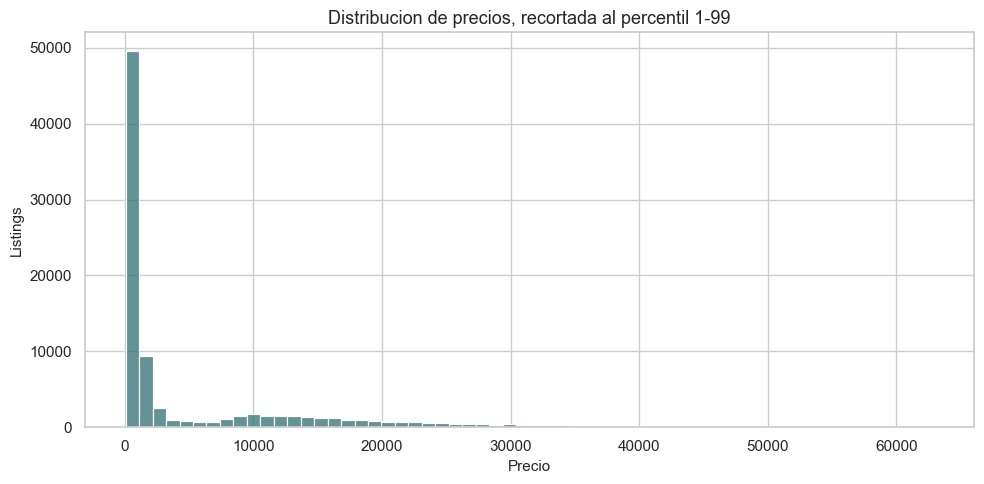

Figura guardada: outputs\figures\reg_eda_rating_distribution.png


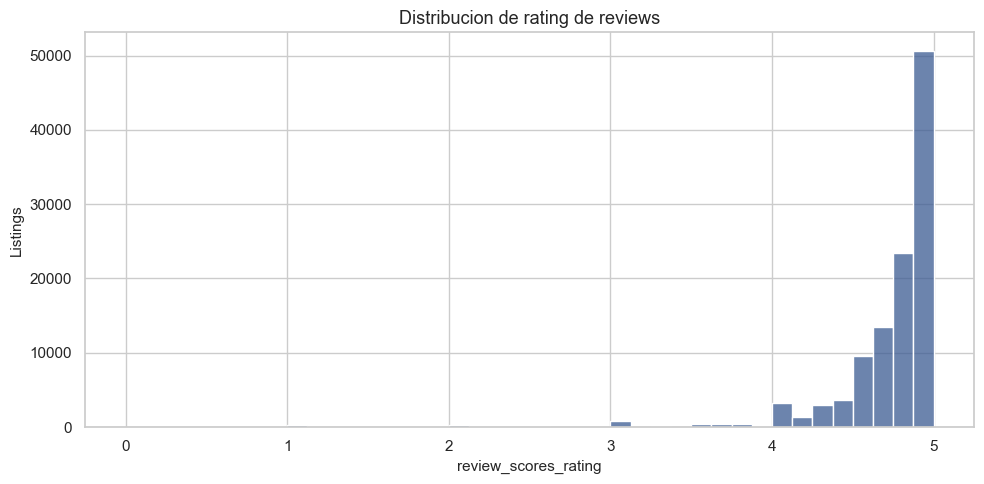

In [9]:
def save_current_fig(filename: str):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Figura guardada: {path.relative_to(PROJECT_ROOT)}")

if "price" in listings.columns:
    price_plot = pd.to_numeric(listings["price"], errors="coerce").dropna()
    price_plot = price_plot[(price_plot >= price_plot.quantile(0.01)) & (price_plot <= price_plot.quantile(0.99))]
    if len(price_plot) > 0:
        plt.figure(figsize=(10, 5))
        sns.histplot(price_plot, bins=60, color="#2f6f73")
        plt.title("Distribucion de precios, recortada al percentil 1-99")
        plt.xlabel("Precio")
        plt.ylabel("Listings")
        save_current_fig("reg_eda_price_distribution.png")
        plt.show()

if "review_scores_rating" in listings.columns:
    rating_plot = pd.to_numeric(listings["review_scores_rating"], errors="coerce").dropna()
    if len(rating_plot) > 0:
        plt.figure(figsize=(10, 5))
        sns.histplot(rating_plot, bins=40, color="#3b5b92")
        plt.title("Distribucion de rating de reviews")
        plt.xlabel("review_scores_rating")
        plt.ylabel("Listings")
        save_current_fig("reg_eda_rating_distribution.png")
        plt.show()

## 3. Preparacion de los datos

### Definicion de la variable objetivo

La variable `high_risk_listing` se define asi:

- Si existe `data/gold/analytics/listing_trust_risk`, se toma `risk_segment` como proxy academico: `High` o `Critical` = 1; `Low` o `Moderate` = 0.
- Si ese mart no existe, se calcula una regla fallback con senales disponibles: rating bajo o ausente, poca evidencia de reviews, host no verificado, no superhost, baja respuesta/aceptacion, informacion incompleta, disponibilidad alta con baja demanda y precio atipico.

Esta etiqueta no debe interpretarse como disputa real. Es una aproximacion para fines de TB3 y para alinear el modelo con el dashboard de confianza/riesgo.

In [10]:
def normalize_bool_series(series: pd.Series) -> pd.Series:
    if str(series.dtype) == "boolean" or series.dtype == bool:
        return series.astype("boolean")
    normalized = series.astype(str).str.strip().str.lower()
    true_values = {"true", "t", "1", "yes", "y", "si", "s"}
    false_values = {"false", "f", "0", "no", "n"}
    return normalized.map(lambda value: True if value in true_values else (False if value in false_values else pd.NA)).astype("boolean")

def clean_numeric_series(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = series.astype(str).str.replace(r"[$,%]", "", regex=True).str.replace(",", "", regex=False)
    cleaned = cleaned.replace({"nan": np.nan, "None": np.nan, "<NA>": np.nan})
    return pd.to_numeric(cleaned, errors="coerce")

risk_columns_to_merge = [
    "listing_id",
    "risk_segment",
    "observed_reviews",
    "last_observed_review_date",
    "review_recency_days",
    "country",
    "market_label",
    "host_is_superhost_bool",
    "host_identity_verified_bool",
]
model_df = listings.copy()
if risk is not None and "listing_id" in risk.columns:
    merge_cols = [c for c in risk_columns_to_merge if c in risk.columns]
    model_df = model_df.merge(risk[merge_cols].drop_duplicates("listing_id"), on="listing_id", how="left")

if "risk_segment" in model_df.columns:
    model_df["high_risk_listing"] = model_df["risk_segment"].astype(str).isin(["High", "Critical"]).astype(int)
    target_definition = "risk_segment High/Critical del mart listing_trust_risk"
else:
    points = pd.Series(0, index=model_df.index, dtype="float64")
    if "review_scores_rating" in model_df.columns:
        rating = clean_numeric_series(model_df["review_scores_rating"])
        points += rating.isna().astype(int)
        points += (rating < 4.5).fillna(False).astype(int) * 2
    review_signal = None
    for candidate in ["observed_reviews", "number_of_reviews"]:
        if candidate in model_df.columns:
            review_signal = clean_numeric_series(model_df[candidate])
            break
    if review_signal is not None:
        points += (review_signal.fillna(0) <= 1).astype(int) * 2
    for col in ["host_identity_verified", "host_identity_verified_bool"]:
        if col in model_df.columns:
            points += normalize_bool_series(model_df[col]).eq(False).fillna(False).astype(int) * 2
            break
    for col in ["host_is_superhost", "host_is_superhost_bool"]:
        if col in model_df.columns:
            points += normalize_bool_series(model_df[col]).eq(False).fillna(False).astype(int)
            break
    for col in ["host_response_rate", "host_acceptance_rate"]:
        if col in model_df.columns:
            rate = clean_numeric_series(model_df[col])
            points += (rate < 0.5).fillna(False).astype(int)
    if "availability_365" in model_df.columns and review_signal is not None:
        availability = clean_numeric_series(model_df["availability_365"])
        points += ((availability > 300) & (review_signal.fillna(0) <= 1)).fillna(False).astype(int)
    if "price" in model_df.columns:
        price = clean_numeric_series(model_df["price"])
        points += ((price > price.quantile(0.95)) | (price < price.quantile(0.01))).fillna(False).astype(int)
    model_df["high_risk_listing"] = (points >= 5).astype(int)
    target_definition = "proxy fallback calculado con senales de calidad, host, reviews, completitud y precio"

print("Definicion de target:", target_definition)
display(model_df["high_risk_listing"].value_counts(normalize=True).rename("proporcion").to_frame())
display(model_df["high_risk_listing"].value_counts().rename("filas").to_frame())

Definicion de target: risk_segment High/Critical del mart listing_trust_risk


,proporcion
high_risk_listing,
0,0.908934
1,0.091066


,filas
high_risk_listing,
0,124174
1,12441


Figura guardada: outputs\figures\reg_target_distribution.png


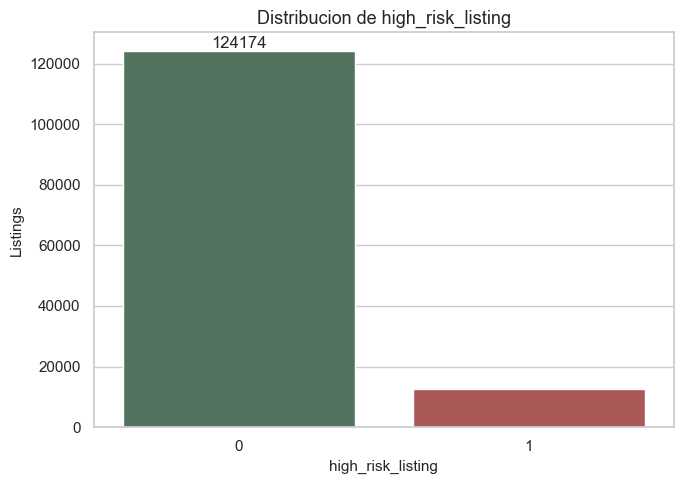

In [11]:
target_counts = model_df["high_risk_listing"].value_counts().sort_index()
plt.figure(figsize=(7, 5))
ax = sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, palette=["#4c7a5d", "#b84a4a"])
ax.bar_label(ax.containers[0], fmt="%d")
plt.title("Distribucion de high_risk_listing")
plt.xlabel("high_risk_listing")
plt.ylabel("Listings")
save_current_fig("reg_target_distribution.png")
plt.show()

In [12]:
if "description" in model_df.columns:
    model_df["description_length"] = model_df["description"].fillna("").astype(str).str.len()
if "name" in model_df.columns:
    model_df["name_length"] = model_df["name"].fillna("").astype(str).str.len()
if "host_since" in model_df.columns:
    host_since = pd.to_datetime(model_df["host_since"], errors="coerce")
    if "last_scraped" in model_df.columns:
        reference_date = pd.to_datetime(model_df["last_scraped"], errors="coerce").max()
    else:
        reference_date = pd.Timestamp.today().normalize()
    model_df["host_tenure_days"] = (reference_date - host_since).dt.days

numeric_candidates = [
    "price",
    "price_per_accommodates",
    "availability_365",
    "review_scores_rating",
    "number_of_reviews",
    "reviews_per_month",
    "observed_reviews",
    "review_recency_days",
    "host_response_rate",
    "host_acceptance_rate",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "description_length",
    "name_length",
    "host_tenure_days",
    "latitude",
    "longitude",
]
categorical_candidates = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "country",
    "market_label",
    "host_is_superhost",
    "host_identity_verified",
    "host_is_superhost_bool",
    "host_identity_verified_bool",
]

numeric_features = [c for c in numeric_candidates if c in model_df.columns]
categorical_features = [c for c in categorical_candidates if c in model_df.columns]

for col in numeric_features:
    model_df[col] = clean_numeric_series(model_df[col])
for col in categorical_features:
    cat_series = model_df[col].astype("string").fillna("Missing")
    top_values = cat_series.value_counts(dropna=False).head(25).index
    model_df[col] = cat_series.where(cat_series.isin(top_values), "Other").astype(str)

leakage_columns = {
    "high_risk_listing",
    "risk_segment",
    "risk_score",
    "trust_score",
    "quality_risk",
    "host_trust_risk",
    "review_confidence_risk",
    "listing_completeness_risk",
    "price_market_risk",
    "primary_risk_driver",
    "dispute_cause_proxy",
    "recommended_action",
    "listing_lifecycle_stage",
}
feature_columns = [c for c in numeric_features + categorical_features if c not in leakage_columns]

modeling_data = model_df[feature_columns + ["high_risk_listing"]].copy()
modeling_data = modeling_data.dropna(subset=["high_risk_listing"])

print(f"Features numericas ({len(numeric_features)}): {numeric_features}")
print(f"Features categoricas ({len(categorical_features)}): {categorical_features}")
print("Shape modeling_data:", modeling_data.shape)
display(modeling_data.head(3))

Features numericas (21): ['price', 'price_per_accommodates', 'availability_365', 'review_scores_rating', 'number_of_reviews', 'reviews_per_month', 'observed_reviews', 'review_recency_days', 'host_response_rate', 'host_acceptance_rate', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'description_length', 'name_length', 'host_tenure_days', 'latitude', 'longitude']
Features categoricas (9): ['room_type', 'property_type', 'neighbourhood_cleansed', 'country', 'market_label', 'host_is_superhost', 'host_identity_verified', 'host_is_superhost_bool', 'host_identity_verified_bool']
Shape modeling_data: (136615, 31)


,price,price_per_accommodates,availability_365,review_scores_rating,number_of_reviews,reviews_per_month,observed_reviews,review_recency_days,host_response_rate,host_acceptance_rate,...,room_type,property_type,neighbourhood_cleansed,country,market_label,host_is_superhost,host_identity_verified,host_is_superhost_bool,host_identity_verified_bool,high_risk_listing
0,<NA>,<NA>,326,4.83,83,0.45,83.0,154.0,<NA>,<NA>,...,Private room,Private room in condo,Other,Spain,Girona / Costa Brava,False,True,False,True,0
1,356.0,71.2,235,4.71,341,1.84,341.0,150.0,1.0,0.95,...,Entire home/apt,Entire condo,Copacabana,Brazil,Rio de Janeiro,False,True,False,True,0
2,<NA>,<NA>,115,4.36,54,0.35,54.0,87.0,0.95,0.9,...,Entire home/apt,Entire rental unit,Other,Spain,Barcelona,False,True,False,True,0


## 4. Modelado

Se entrena una regresion logistica base y una regresion logistica con `class_weight='balanced'`. La segunda suele ser util cuando la clase de alto riesgo es minoritaria. No se usa `risk_score`, `trust_score`, `risk_segment` ni componentes del score como variables predictoras.

In [13]:
if modeling_data["high_risk_listing"].nunique() < 2:
    raise ValueError("La variable objetivo tiene una sola clase. No es posible entrenar clasificacion binaria.")

X = modeling_data[feature_columns]
y = modeling_data["high_risk_listing"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", encoder)]), categorical_features),
    ],
    remainder="drop",
)

model_specs = {
    "logistic_base": LogisticRegression(max_iter=1200, solver="liblinear", random_state=RANDOM_STATE),
    "logistic_balanced": LogisticRegression(max_iter=1200, solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE),
}

trained_models = {}
metrics_rows = []

for model_name, estimator in model_specs.items():
    pipeline = Pipeline([("preprocess", preprocess), ("model", estimator)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1]
    metrics_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "positive_rate_train": y_train.mean(),
        "positive_rate_test": y_test.mean(),
        "target_definition": target_definition,
    })
    trained_models[model_name] = {"pipeline": pipeline, "y_pred": y_pred, "y_score": y_score}

metrics = pd.DataFrame(metrics_rows).sort_values(["f1", "roc_auc"], ascending=False)
metrics_path = OUTPUT_DIR / "metrics_regresion_logistica.csv"
metrics.to_csv(metrics_path, index=False)
display(metrics)
print(f"Metricas guardadas: {metrics_path.relative_to(PROJECT_ROOT)}")

best_model_name = metrics.iloc[0]["model"]
best_pipeline = trained_models[best_model_name]["pipeline"]
best_y_pred = trained_models[best_model_name]["y_pred"]
best_y_score = trained_models[best_model_name]["y_score"]
print("Mejor modelo por F1:", best_model_name)

,model,accuracy,precision,recall,f1,roc_auc,train_rows,test_rows,positive_rate_train,positive_rate_test,target_definition
0,logistic_base,0.973429,0.861362,0.844051,0.852619,0.990283,109292,27323,0.091068,0.091059,risk_segment High/Critical del mart listing_tr...
1,logistic_balanced,0.940160,0.608552,0.961013,0.745208,0.989818,109292,27323,0.091068,0.091059,risk_segment High/Critical del mart listing_tr...


Metricas guardadas: outputs\metrics_regresion_logistica.csv
Mejor modelo por F1: logistic_base


## 5. Evaluacion

Se reportan accuracy, precision, recall, F1 y ROC-AUC. Para Trust & Safety, precision ayuda a controlar falsos positivos operativos; recall indica cuanta poblacion de riesgo se detecta; F1 balancea ambas dimensiones. Como la etiqueta es proxy, estas metricas no prueban reduccion real de disputas.

Figura guardada: outputs\figures\reg_confusion_matrix.png


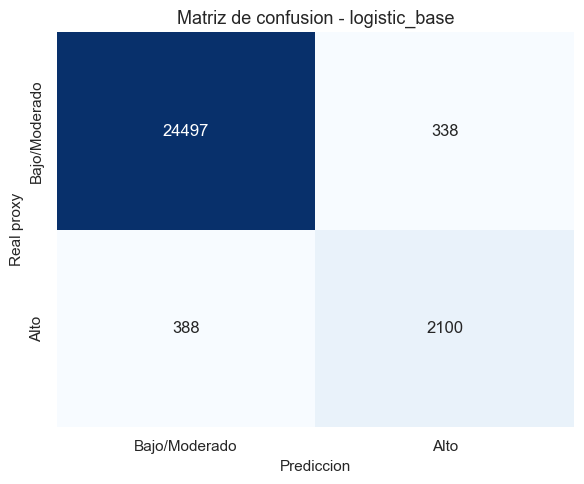

Figura guardada: outputs\figures\reg_roc_curve.png


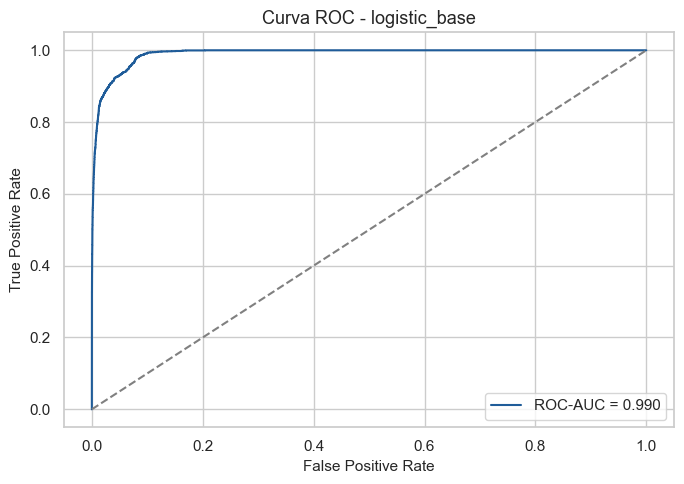

Figura guardada: outputs\figures\reg_precision_recall_curve.png


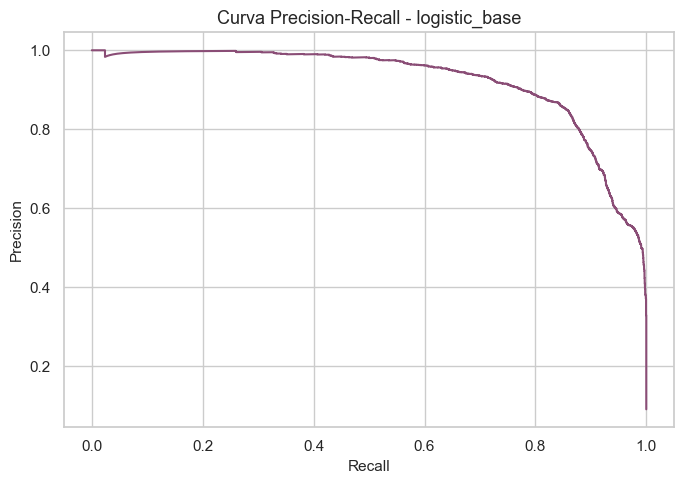

In [14]:
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Bajo/Moderado", "Alto"],
    yticklabels=["Bajo/Moderado", "Alto"],
)
plt.title(f"Matriz de confusion - {best_model_name}")
plt.xlabel("Prediccion")
plt.ylabel("Real proxy")
save_current_fig("reg_confusion_matrix.png")
plt.show()

fpr, tpr, _ = roc_curve(y_test, best_y_score)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#1f5c99", label=f"ROC-AUC = {roc_auc_score(y_test, best_y_score):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title(f"Curva ROC - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
save_current_fig("reg_roc_curve.png")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, best_y_score)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color="#8a4d76")
plt.title(f"Curva Precision-Recall - {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
save_current_fig("reg_precision_recall_curve.png")
plt.show()

,feature,coefficient,abs_coefficient
7,num__review_recency_days,3.847824,3.847824
94,cat__host_identity_verified_True,-2.934914,2.934914
98,cat__host_identity_verified_bool_True,-2.934914,2.934914
4,num__number_of_reviews,-2.889544,2.889544
6,num__observed_reviews,-2.889544,2.889544
96,cat__host_is_superhost_bool_True,-1.885876,1.885876
91,cat__host_is_superhost_True,-1.885876,1.885876
82,cat__market_label_Asheville,-1.259553,1.259553
2,num__availability_365,1.184024,1.184024
3,num__review_scores_rating,-1.041613,1.041613


Coeficientes guardados: outputs\model_coefficients_regresion_logistica.csv
Figura guardada: outputs\figures\reg_top_coefficients.png


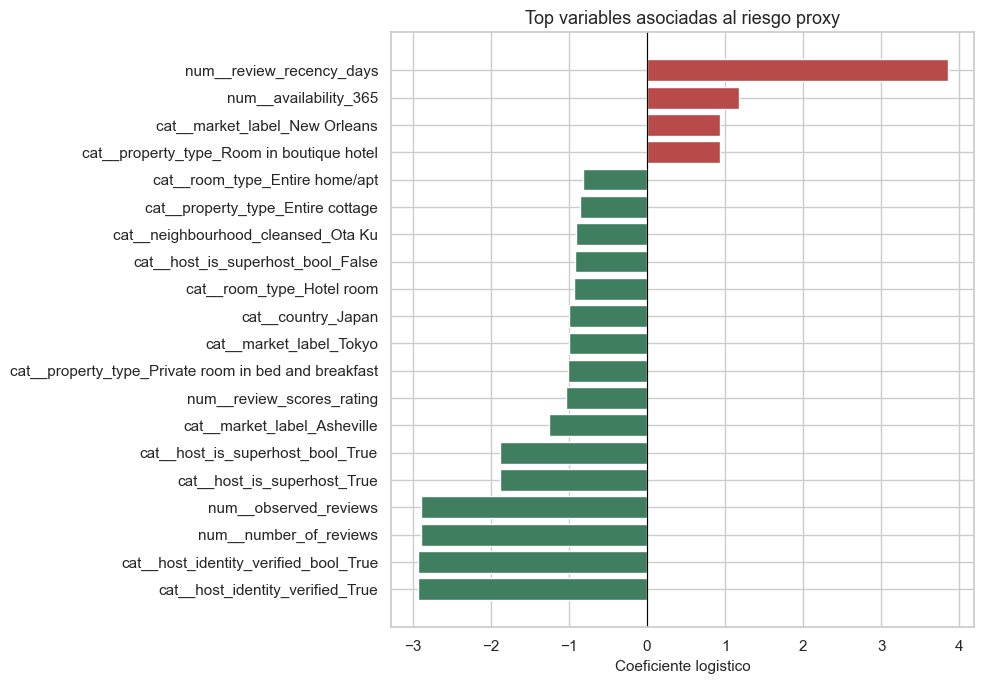

In [15]:
def get_feature_names(preprocessor: ColumnTransformer):
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        names = []
        names.extend(numeric_features)
        if categorical_features:
            encoder_step = preprocessor.named_transformers_["cat"].named_steps["onehot"]
            try:
                names.extend(encoder_step.get_feature_names_out(categorical_features))
            except Exception:
                names.extend(categorical_features)
        return np.array(names)

feature_names = get_feature_names(best_pipeline.named_steps["preprocess"])
coefficients = best_pipeline.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
coef_path = OUTPUT_DIR / "model_coefficients_regresion_logistica.csv"
coef_df.to_csv(coef_path, index=False)
display(coef_df.head(25))
print(f"Coeficientes guardados: {coef_path.relative_to(PROJECT_ROOT)}")

top_coef = coef_df.head(20).sort_values("coefficient")
plt.figure(figsize=(10, 7))
colors = np.where(top_coef["coefficient"] >= 0, "#b84a4a", "#3f7f5f")
plt.barh(top_coef["feature"], top_coef["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top variables asociadas al riesgo proxy")
plt.xlabel("Coeficiente logistico")
save_current_fig("reg_top_coefficients.png")
plt.show()

In [16]:
model_artifact = {
    "model_name": best_model_name,
    "pipeline": best_pipeline,
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": "high_risk_listing",
    "target_definition": target_definition,
    "metrics": metrics.to_dict(orient="records"),
}
model_path = MODEL_DIR / "logistic_regression_airbnb.pkl"
joblib.dump(model_artifact, model_path)
print(f"Modelo guardado: {model_path.relative_to(PROJECT_ROOT)}")

Modelo guardado: outputs\models\logistic_regression_airbnb.pkl


## 6. Implementacion

El modelo se puede integrar al dashboard de confianza/riesgo como una capa de scoring complementaria al `risk_score` explicable. En un flujo operativo, la probabilidad estimada podria alimentar una cola de revision priorizada por mercado, tipo de habitacion o etapa del listing.

**Conclusiones para TB3**

- Las variables con coeficiente positivo aumentan la probabilidad de pertenecer al segmento de alto riesgo proxy; las negativas reducen esa probabilidad.
- Para Trust & Safety, el modelo es util como priorizador academico, no como evidencia de disputa real.
- La principal limitacion es la falta de reservas, disputas, tickets de soporte y fecha de primera reserva. Por ello, las metricas son contra una etiqueta proxy y no deben presentarse como precision real de negocio.
- Para produccion, el siguiente paso seria reemplazar `high_risk_listing` por una etiqueta real `severe_dispute_flag` y entrenar con snapshots anteriores a la primera reserva.